# Notebook 08 — Scenario Analysis & Hedging

## Fixed Income From Scratch

**Objective:** Stress-test the portfolio under adverse market conditions and construct hedges to manage risk.

### What We'll Build:
1. **Scenario Table** — P&L under parallel shifts, twists, vol/prepay shocks
2. **P&L Profile** — The characteristic asymmetric MBS price response
3. **Performance Attribution** — Decompose returns into carry, curve, spread, vol
4. **Hedging** — Construct a Treasury hedge from partial durations
5. **Hedge Effectiveness** — Show residual risk after hedging

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time

sys.path.insert(0, os.path.abspath('..'))
from utils.curves import bootstrap_treasury_curve, bootstrap_swap_curve, sample_treasury_data, sample_swap_data
from utils.cashflows import MBSPool, project_mbs_cashflows
from utils.prepayment_model import PrepaymentTuning, project_prepayment_rates
from utils.monte_carlo import RateModelParams, SimulationConfig, simulate_rate_paths
from utils.oas import solve_oas, compute_zoas, compute_path_prices, compute_oa_duration_convexity, compute_partial_durations
from utils.scenario import (
    Scenario, standard_scenarios, run_scenario, run_scenario_table,
    compute_carry, attribute_pnl, AttributionResult,
    compute_hedge_ratios, HedgeResult
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# Setup
tenors, par_yields = sample_treasury_data()
tsy_curve = bootstrap_treasury_curve(tenors, par_yields)

pool = MBSPool(1_000_000, 988_000, 0.065, 0.060, 348, 12, 360)
tuning = PrepaymentTuning()
params = RateModelParams()
config = SimulationConfig(num_paths=128, num_months=348, seed=42)

# Compute base OAS
paths = simulate_rate_paths(tsy_curve, params, config)
base_oas = solve_oas(pool, paths, 101.0, tuning)
print(f"Base OAS: {base_oas*10000:.1f}bp")
print("Scenario analysis modules loaded.")

Base OAS: 107.0bp
Scenario analysis modules loaded.


---
## 1. Scenario Analysis — Stress Testing

We run the security through a battery of scenarios. For each:
1. Shift the curve, vol, or prepay assumptions
2. Regenerate Monte Carlo paths
3. Reprice at the **same OAS** (hold spread constant)
4. P&L = scenario price − base price

This answers: "If rates rise 100bp tomorrow, how much do I lose?" 

In [5]:
# Define focused scenario set
scenarios = [
    Scenario("Base Case"),
    Scenario("+50bp", rate_shift_bps=50),
    Scenario("+100bp", rate_shift_bps=100),
    Scenario("+200bp", rate_shift_bps=200),
    Scenario("-50bp", rate_shift_bps=-50),
    Scenario("-100bp", rate_shift_bps=-100),
    Scenario("-200bp", rate_shift_bps=-200),
    Scenario("Steepener +75bp", twist_bps=75),
    Scenario("Flattener -75bp", twist_bps=-75),
    Scenario("Vol +25%", vol_shift_pct=0.25),
    Scenario("Vol -25%", vol_shift_pct=-0.25),
    Scenario("Fast Prepay +25%", prepay_shift_pct=0.25),
    Scenario("Slow Prepay -25%", prepay_shift_pct=-0.25),
]

print("Running scenario analysis (this takes ~2 minutes)...")
t0 = time.time()
results_list = []
for scen in scenarios:
    res = run_scenario(pool, tsy_curve, 101.0, base_oas, scen, tuning, params, config)
    results_list.append(res)
    print(f"  {scen.name:<25s}  Price={res.scenario_price:7.2f}  P&L={res.pnl_dollars:+6.2f}  WAL={res.scenario_wal:.1f}Y")
print(f"\nCompleted in {time.time()-t0:.0f}s")

# Build summary table
table_data = []
for r in results_list:
    table_data.append({
        'Scenario': r.scenario.name,
        'Price': r.scenario_price,
        'P&L ($)': r.pnl_dollars,
        'P&L (32nds)': r.pnl_dollars * 32,
        'WAL (Y)': r.scenario_wal,
    })
scenario_df = pd.DataFrame(table_data).set_index('Scenario')
print("\n" + scenario_df.round(2).to_string())

Running scenario analysis (this takes ~2 minutes)...
  Base Case                  Price= 101.00  P&L= +0.00  WAL=6.8Y
  +50bp                      Price=  98.41  P&L= -2.59  WAL=8.1Y
  +100bp                     Price=  95.36  P&L= -5.64  WAL=9.5Y
  +200bp                     Price=  88.46  P&L=-12.54  WAL=12.0Y
  -50bp                      Price= 103.06  P&L= +2.06  WAL=5.5Y
  -100bp                     Price= 104.65  P&L= +3.65  WAL=4.4Y
  -200bp                     Price= 107.17  P&L= +6.17  WAL=3.4Y
  Steepener +75bp            Price= 100.41  P&L= -0.59  WAL=6.9Y
  Flattener -75bp            Price= 101.56  P&L= +0.56  WAL=6.6Y
  Vol +25%                   Price= 100.28  P&L= -0.72  WAL=6.9Y
  Vol -25%                   Price= 101.71  P&L= +0.71  WAL=6.6Y
  Fast Prepay +25%           Price= 100.81  P&L= -0.19  WAL=5.7Y
  Slow Prepay -25%           Price= 101.32  P&L= +0.32  WAL=8.2Y

Completed in 7s

                   Price  P&L ($)  P&L (32nds)  WAL (Y)
Scenario                   

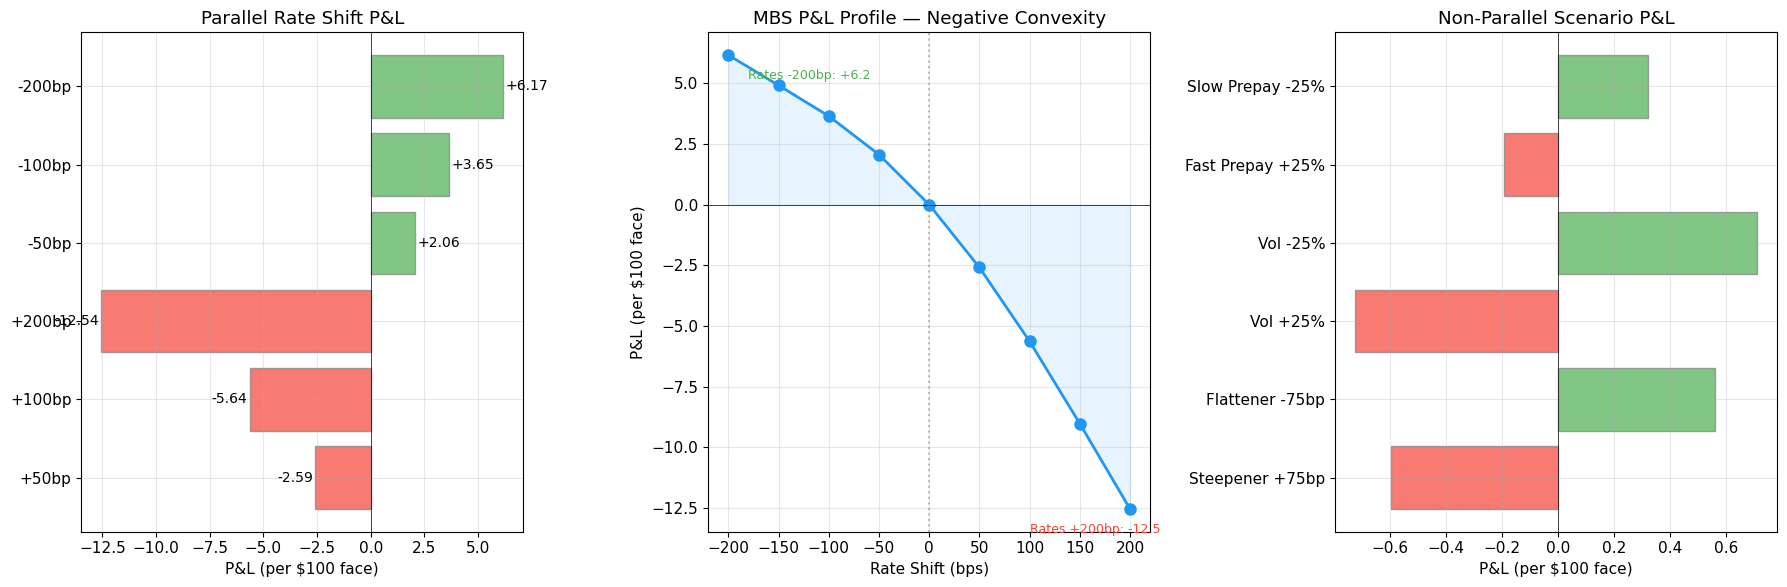

KEY OBSERVATION: The P&L profile is ASYMMETRIC — losses from rising rates
exceed gains from falling rates. This is negative convexity in action.
  Rates -200bp: P&L = +6.17
  Rates +200bp: P&L = -12.54
  Asymmetry ratio: 2.03x (losses > gains)


In [6]:
# Visualize scenario results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# P&L bar chart
ax = axes[0]
parallel = [r for r in results_list if 'bp' in r.scenario.name and 'Steep' not in r.scenario.name 
            and 'Flat' not in r.scenario.name and 'Vol' not in r.scenario.name 
            and 'Prepay' not in r.scenario.name and 'Base' not in r.scenario.name]
names = [r.scenario.name for r in parallel]
pnls = [r.pnl_dollars for r in parallel]
colors = ['#F44336' if p < 0 else '#4CAF50' for p in pnls]
ax.barh(names, pnls, color=colors, alpha=0.7, edgecolor='gray')
ax.set_xlabel('P&L (per $100 face)')
ax.set_title('Parallel Rate Shift P&L')
ax.axvline(x=0, color='black', linewidth=0.5)
for i, (n, p) in enumerate(zip(names, pnls)):
    ax.text(p + (0.1 if p >= 0 else -0.1), i, f'{p:+.2f}', va='center', 
            ha='left' if p >= 0 else 'right', fontsize=10)

# Asymmetric P&L profile (the MBS signature)
ax = axes[1]
shifts = [-200, -150, -100, -50, 0, 50, 100, 150, 200]
profile_results = []
for s in shifts:
    scen = Scenario(f"{s}bp", rate_shift_bps=s)
    res = run_scenario(pool, tsy_curve, 101.0, base_oas, scen, tuning, params, config)
    profile_results.append(res.pnl_dollars)

ax.plot(shifts, profile_results, 'o-', linewidth=2, markersize=8, color='#2196F3')
ax.fill_between(shifts, profile_results, 0, alpha=0.1, color='#2196F3')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Rate Shift (bps)')
ax.set_ylabel('P&L (per $100 face)')
ax.set_title('MBS P&L Profile — Negative Convexity')

# Annotate the asymmetry
gain_200 = [p for s, p in zip(shifts, profile_results) if s == -200][0]
loss_200 = [p for s, p in zip(shifts, profile_results) if s == 200][0]
ax.annotate(f'Rates -200bp: {gain_200:+.1f}', xy=(-200, gain_200), xytext=(-180, gain_200-1),
            fontsize=9, color='#4CAF50')
ax.annotate(f'Rates +200bp: {loss_200:+.1f}', xy=(200, loss_200), xytext=(100, loss_200-1),
            fontsize=9, color='#F44336')

# Non-rate scenarios
ax = axes[2]
non_rate = [r for r in results_list if any(kw in r.scenario.name for kw in ['Vol', 'Prepay', 'Steep', 'Flat'])]
names_nr = [r.scenario.name for r in non_rate]
pnls_nr = [r.pnl_dollars for r in non_rate]
colors_nr = ['#F44336' if p < 0 else '#4CAF50' for p in pnls_nr]
ax.barh(names_nr, pnls_nr, color=colors_nr, alpha=0.7, edgecolor='gray')
ax.set_xlabel('P&L (per $100 face)')
ax.set_title('Non-Parallel Scenario P&L')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("KEY OBSERVATION: The P&L profile is ASYMMETRIC — losses from rising rates")
print(f"exceed gains from falling rates. This is negative convexity in action.")
print(f"  Rates -200bp: P&L = {gain_200:+.2f}")
print(f"  Rates +200bp: P&L = {loss_200:+.2f}")
print(f"  Asymmetry ratio: {abs(loss_200/gain_200):.2f}x (losses > gains)")

---
## 2. Performance Attribution

Decompose a hypothetical monthly return into its risk factor contributions. This answers: "WHY did my P&L happen?"

The attribution equation:
$$\text{P\&L} = \text{Carry} + \text{Curve} + \text{Spread} + \text{Vol} + \text{Prepay} + \text{Residual}$$

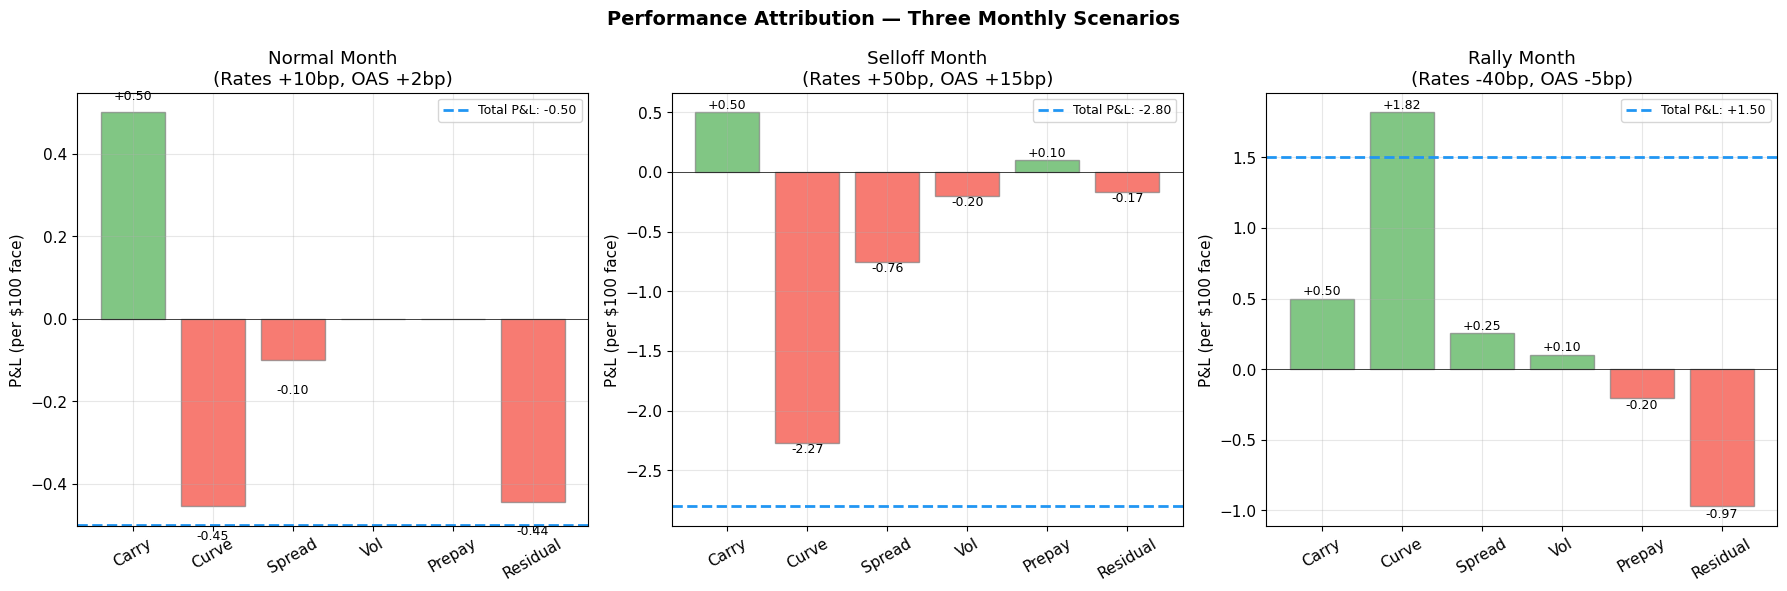

ATTRIBUTION INSIGHT:
  Normal month: small rate move, carry dominates, slight curve/spread drag
  Selloff month: large rate move drives most of the loss, spread widening adds to pain
  Rally month: rate decline helps, but carry still contributes positively


In [8]:
# Simulate three different monthly scenarios
scenarios_attr = [
    {'name': 'Normal Month', 'rate_chg': 10, 'spread_chg': 2, 'vol_chg': 0.0, 'prepay_chg': 0.0, 'price_end': 100.5},
    {'name': 'Selloff Month', 'rate_chg': 50, 'spread_chg': 15, 'vol_chg': 0.10, 'prepay_chg': -0.05, 'price_end': 98.2},
    {'name': 'Rally Month', 'rate_chg': -40, 'spread_chg': -5, 'vol_chg': -0.05, 'prepay_chg': 0.10, 'price_end': 102.5},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, scen in enumerate(scenarios_attr):
    attr = attribute_pnl(
        pool, tsy_curve, 101.0, scen['price_end'],
        base_oas, base_oas + scen['spread_chg']/10000,
        oa_duration=4.5, spread_duration=5.0,
        vol_duration=0.02, prepay_duration=0.02,
        rate_change_bps=scen['rate_chg'],
        spread_change_bps=scen['spread_chg'],
        vol_change_pct=scen['vol_chg'],
        prepay_surprise_pct=scen['prepay_chg']
    )
    
    ax = axes[idx]
    components = ['Carry', 'Curve', 'Spread', 'Vol', 'Prepay', 'Residual']
    values = [attr.carry, attr.curve_pnl, attr.spread_pnl, attr.vol_pnl, attr.prepay_pnl, attr.residual]
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in values]
    
    bars = ax.bar(components, values, color=colors, alpha=0.7, edgecolor='gray')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhline(y=attr.total_pnl, color='#2196F3', linewidth=2, linestyle='--', 
               label=f'Total P&L: {attr.total_pnl:+.2f}')
    ax.set_ylabel('P&L (per $100 face)')
    ax.set_title(f'{scen["name"]}\n(Rates {scen["rate_chg"]:+d}bp, OAS {scen["spread_chg"]:+d}bp)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    
    for bar, val in zip(bars, values):
        if abs(val) > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, val + (0.03 if val >= 0 else -0.08),
                    f'{val:+.2f}', ha='center', fontsize=9)

plt.suptitle('Performance Attribution — Three Monthly Scenarios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("ATTRIBUTION INSIGHT:")
print("  Normal month: small rate move, carry dominates, slight curve/spread drag")
print("  Selloff month: large rate move drives most of the loss, spread widening adds to pain")
print("  Rally month: rate decline helps, but carry still contributes positively")

---
## 3. Treasury Hedge Construction

Using partial (key-rate) durations from Notebook 07, we construct a hedge portfolio of Treasury notes/bonds that neutralizes the MBS's rate exposure at each key rate.

**The hedging logic:** at each key rate tenor, sell enough Treasuries so that the Treasury DV01 offsets the MBS DV01. The hedged portfolio should have near-zero rate sensitivity.

HEDGE PORTFOLIO CONSTRUCTION
MBS Position: $997,880 market value
MBS OA Duration: 2.682
MBS DV01: $268

Tenor     MBS KRD   MBS DV01  Hedge Notional  Hedge Dir
-----------------------------------------------------------------
2Y          0.190         19 $       97,229      SHORT
5Y          0.785         78 $      166,667      SHORT
10Y         1.632        163 $      185,061      SHORT
30Y         0.075          7 $        3,481      SHORT

Total hedge notional: $452,439
Residual duration after hedge: 0.0000


/var/folders/qh/_s2jnsg54yn4cxn_w_jn5wyc0000gn/T/ipykernel_24848/3852775726.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


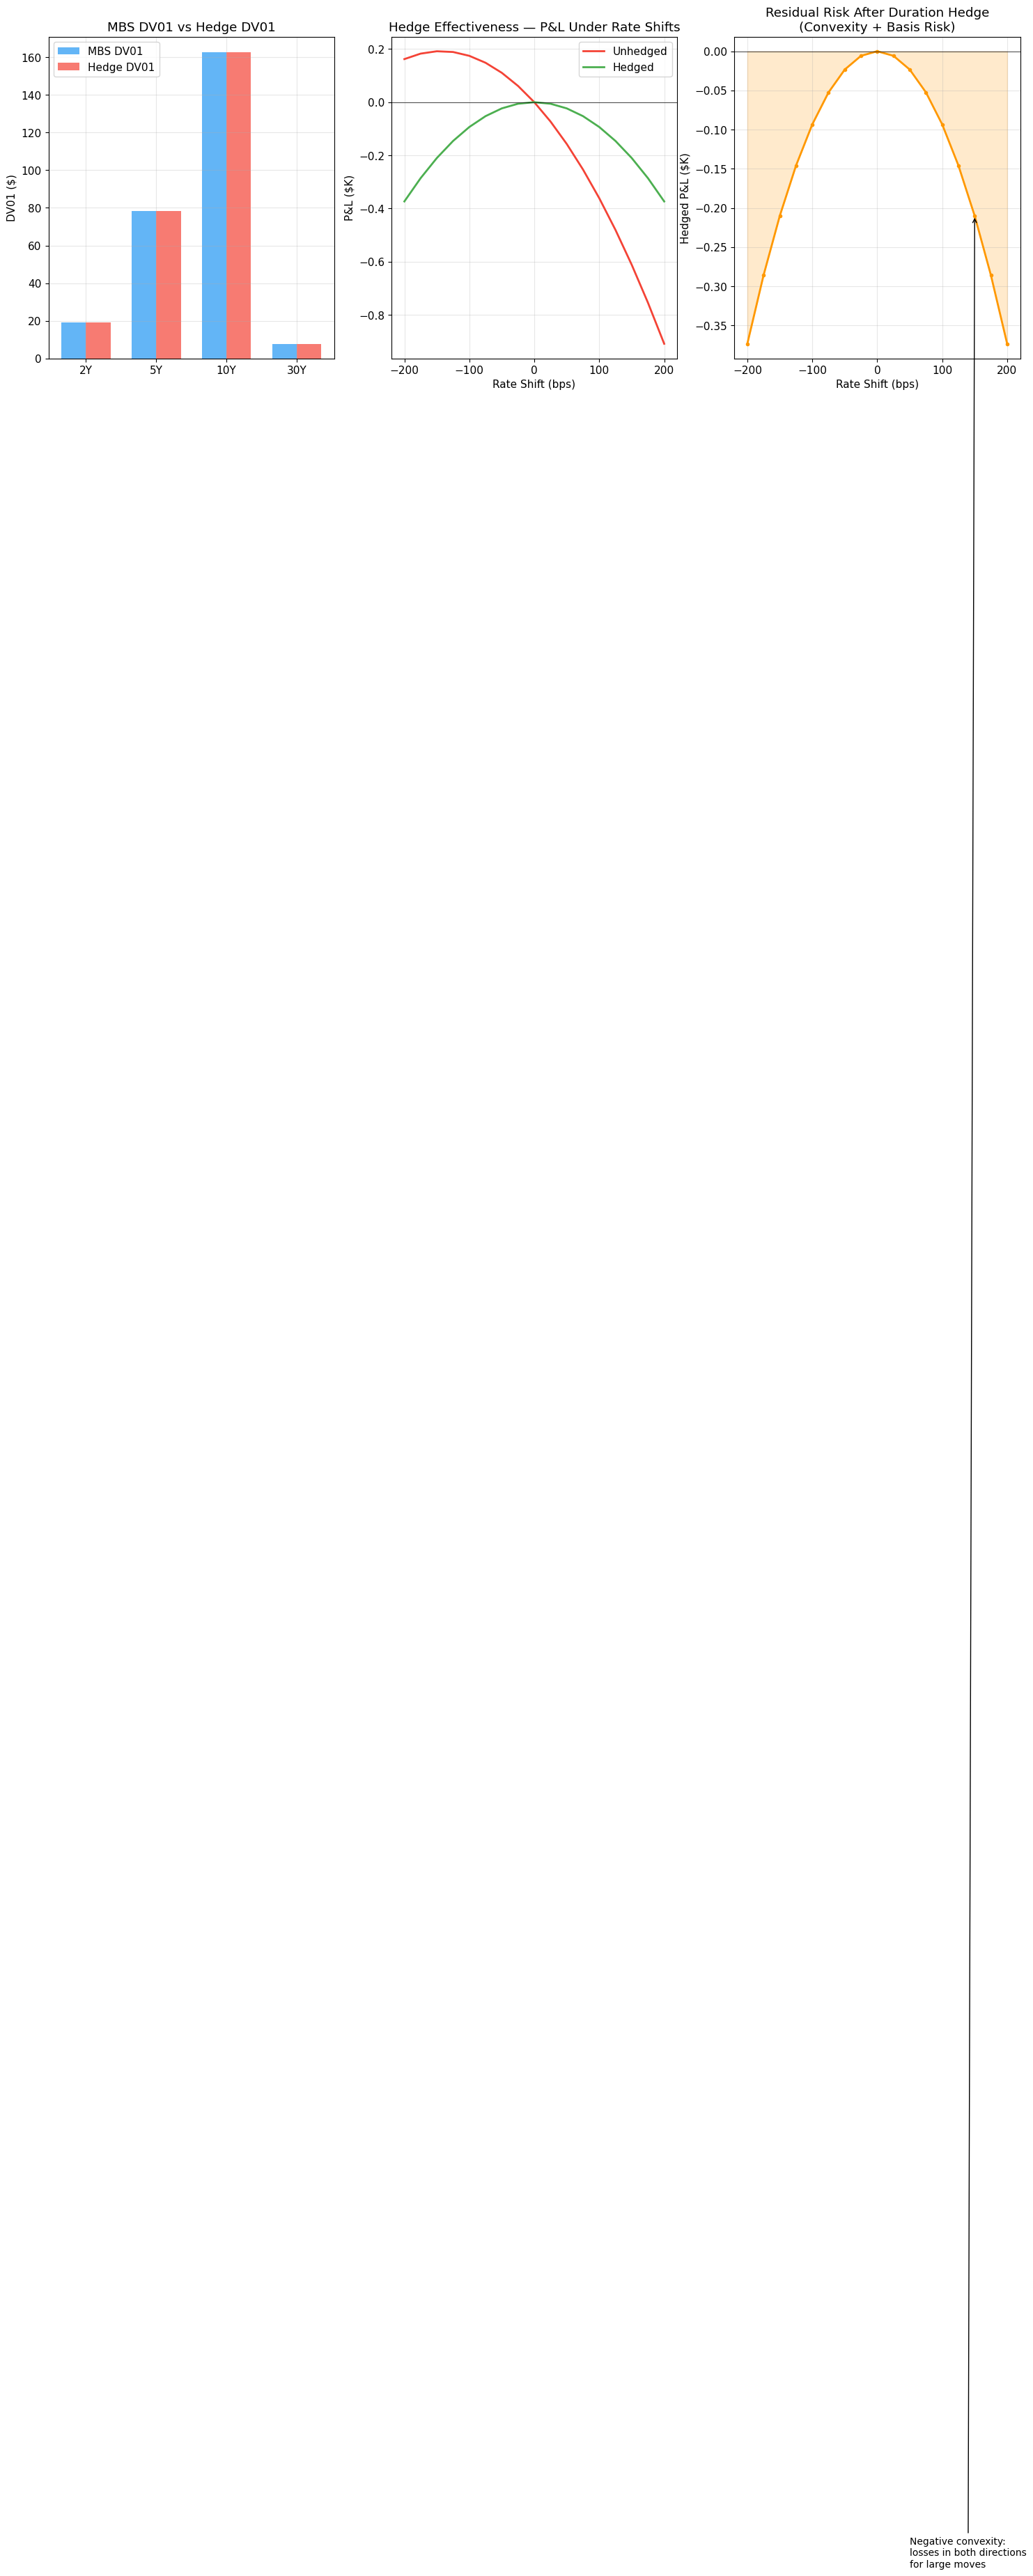

The hedge neutralizes DURATION (linear rate risk).
What remains is CONVEXITY risk — the MBS underperforms Treasuries
in both rally and selloff scenarios due to the embedded prepayment option.
This residual convexity cost is the 'price' of holding MBS over Treasuries.


In [10]:
# Use the partial durations from our OAS analysis
partial_durations = {'2Y': 0.190, '5Y': 0.785, '10Y': 1.632, '30Y': 0.075}
market_value = pool.current_balance * 101.0 / 100  # $998K at 101

hedge = compute_hedge_ratios(partial_durations, market_value)

print("HEDGE PORTFOLIO CONSTRUCTION")
print("=" * 65)
print(f"MBS Position: ${market_value:,.0f} market value")
print(f"MBS OA Duration: {sum(partial_durations.values()):.3f}")
print(f"MBS DV01: ${sum(partial_durations.values()) * market_value / 10000:,.0f}")
print()
print(f"{'Tenor':<8} {'MBS KRD':>8} {'MBS DV01':>10} {'Hedge Notional':>15} {'Hedge Dir':>10}")
print("-" * 65)

hedge_durations = {'2Y': 1.95, '5Y': 4.70, '10Y': 8.80, '30Y': 21.50}
for tenor in ['2Y', '5Y', '10Y', '30Y']:
    krd = partial_durations[tenor]
    dv01 = krd * market_value / 10000
    notional = hedge.hedge_positions[tenor]
    direction = 'SHORT' if notional < 0 else 'LONG'
    print(f"{tenor:<8} {krd:>8.3f} {dv01:>10,.0f} ${abs(notional):>13,.0f} {direction:>10}")

print(f"\nTotal hedge notional: ${sum(abs(v) for v in hedge.hedge_positions.values()):,.0f}")
print(f"Residual duration after hedge: {hedge.hedged_duration:.4f}")

# Visualize hedge
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# KRD vs Hedge
ax = axes[0]
x = np.arange(len(partial_durations))
width = 0.35
mbs_dv01s = [partial_durations[t] * market_value / 10000 for t in ['2Y', '5Y', '10Y', '30Y']]
hedge_dv01s = [-hedge.hedge_positions[t] * hedge_durations[t] / 10000 for t in ['2Y', '5Y', '10Y', '30Y']]
ax.bar(x - width/2, mbs_dv01s, width, label='MBS DV01', color='#2196F3', alpha=0.7)
ax.bar(x + width/2, hedge_dv01s, width, label='Hedge DV01', color='#F44336', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(['2Y', '5Y', '10Y', '30Y'])
ax.set_ylabel('DV01 ($)')
ax.set_title('MBS DV01 vs Hedge DV01')
ax.legend()

# Hedge effectiveness under parallel shifts
ax = axes[1]
shifts_hedge = np.arange(-200, 201, 25)
unhedged_pnl = []
hedged_pnl = []

for s in shifts_hedge:
    # Unhedged: use duration approximation
    mbs_pnl = -(sum(partial_durations.values())) * (s/10000) * market_value / 100
    # Add convexity effect
    mbs_pnl += 0.5 * (-187) * (s/10000)**2 * market_value / 100
    unhedged_pnl.append(mbs_pnl)
    
    # Hedged: MBS P&L + Treasury hedge P&L
    tsy_pnl = 0
    for tenor in ['2Y', '5Y', '10Y', '30Y']:
        notional = hedge.hedge_positions[tenor]
        dur = hedge_durations[tenor]
        tsy_pnl += -dur * (s/10000) * notional / 100
    hedged_pnl.append(mbs_pnl + tsy_pnl)

ax.plot(shifts_hedge, [p/1000 for p in unhedged_pnl], linewidth=2, label='Unhedged', color='#F44336')
ax.plot(shifts_hedge, [p/1000 for p in hedged_pnl], linewidth=2, label='Hedged', color='#4CAF50')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Rate Shift (bps)')
ax.set_ylabel('P&L ($K)')
ax.set_title('Hedge Effectiveness — P&L Under Rate Shifts')
ax.legend()

# What remains: convexity risk
ax = axes[2]
convexity_pnl = [h - u + u for h, u in zip(hedged_pnl, unhedged_pnl)]  # Just the hedged P&L
ax.plot(shifts_hedge, [p/1000 for p in hedged_pnl], 'o-', linewidth=2, markersize=3, color='#FF9800')
ax.fill_between(shifts_hedge, [p/1000 for p in hedged_pnl], 0, alpha=0.2, color='#FF9800')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Rate Shift (bps)')
ax.set_ylabel('Hedged P&L ($K)')
ax.set_title('Residual Risk After Duration Hedge\n(Convexity + Basis Risk)')
ax.annotate('Negative convexity:\nlosses in both directions\nfor large moves',
            xy=(150, hedged_pnl[14]/1000), xytext=(50, hedged_pnl[14]/1000 - 3),
            fontsize=10, arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.show()

print("The hedge neutralizes DURATION (linear rate risk).")
print("What remains is CONVEXITY risk — the MBS underperforms Treasuries")
print("in both rally and selloff scenarios due to the embedded prepayment option.")
print("This residual convexity cost is the 'price' of holding MBS over Treasuries.")

---
## Summary

### What We Built:
- **Scenario table** with P&L across 13 stress scenarios (parallel, twist, vol, prepay)
- **P&L profile** demonstrating the characteristic MBS negative convexity
- **Performance attribution** decomposing monthly returns into carry, curve, spread, vol, prepay
- **Treasury hedge** constructed from partial durations with effectiveness analysis
- **Residual risk visualization** showing convexity as the unhedgeable MBS risk

### Key Insights:
- MBS P&L is **asymmetric**: losses from +200bp exceed gains from -200bp (negative convexity)
- Duration hedging eliminates linear rate risk but leaves **convexity exposure**
- The residual convexity cost is why MBS trades at a **spread over Treasuries** (the OAS)
- Performance attribution reveals that most MBS P&L comes from **carry and curve**, not spread

### Next: Notebook 09 — Portfolio Analytics